# 08 - Clustering CNEFE 2010 (BA)

Clustering dos setores de 2010 usando **apenas os tipos de logradouro**:
- `tipo`: RUA, FAZENDA, ESTRADA, AVENIDA, TRAVESSA, CAMINHO, SÍTIO, POVOADO…

**O campo `situacao` (urbano/rural) é mantido no DataFrame mas NÃO entra no
clustering** — serve exclusivamente para validar a posteriori se o algoritmo
recuperou a estrutura urbano/rural sem ter recebido essa informação.

Depois cruzamos com os clusters de 2022 para construir a **matriz de transição**:
quais setores mudaram de perfil entre os dois momentos?

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import hdbscan
import umap
from pathlib import Path

con = duckdb.connect()
CNEFE_2010 = "'../data/cnefe_2010/*.snappy.parquet'"
OUTPUT_DIR = Path('../outputs')

In [2]:
# Perfil por setor: proporções de tipo + situacao
df_2010 = con.execute(f"""
    SELECT
        setor AS cod_setor,
        COUNT(*) AS total_enderecos,

        -- situacao
        SUM(CASE WHEN situacao = '1' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_urbano,
        SUM(CASE WHEN situacao = '2' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_rural,

        -- tipos urbanos
        SUM(CASE WHEN tipo = 'RUA'      THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_rua,
        SUM(CASE WHEN tipo = 'AVENIDA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_avenida,
        SUM(CASE WHEN tipo = 'TRAVESSA' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_travessa,
        SUM(CASE WHEN tipo = 'PRACA'    THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_praca,
        SUM(CASE WHEN tipo = 'ALAMEDA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_alameda,
        SUM(CASE WHEN tipo = 'BECO'     THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_beco,

        -- tipos rurais
        SUM(CASE WHEN tipo = 'FAZENDA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_fazenda,
        SUM(CASE WHEN tipo = 'ESTRADA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_estrada,
        SUM(CASE WHEN tipo = 'CAMINHO'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_caminho,
        SUM(CASE WHEN tipo = 'RODOVIA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_rodovia,
        SUM(CASE WHEN tipo = 'SITIO'    THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_sitio,
        SUM(CASE WHEN tipo = 'POVOADO'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_povoado

    FROM read_parquet({CNEFE_2010})
    WHERE uf = '29'
    GROUP BY setor
    HAVING COUNT(*) >= 5
""").df()

print(f'Setores: {len(df_2010):,}')
df_2010.head()

Setores: 23,763


,cod_setor,total_enderecos,prop_urbano,prop_rural,prop_rua,prop_avenida,prop_travessa,prop_praca,prop_alameda,prop_beco,prop_fazenda,prop_estrada,prop_caminho,prop_rodovia,prop_sitio,prop_povoado
0,293330705000185,510,1.0,0.0,0.941176,0.025490,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.021569,0.0,0.0
1,293330705000197,252,1.0,0.0,0.884921,0.000000,0.0,0.115079,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
2,293330705000212,273,1.0,0.0,0.967033,0.032967,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
3,293330705000219,259,1.0,0.0,0.803089,0.050193,0.0,0.000000,0.0,0.0,0.0,0.000000,0.146718,0.000000,0.0,0.0
4,293330705000229,206,0.0,1.0,0.072816,0.000000,0.0,0.000000,0.0,0.0,0.0,0.927184,0.000000,0.000000,0.0,0.0


In [3]:
# prop_urbano e prop_rural são mantidas no df para validação posterior,
# mas NÃO entram no clustering — só os tipos de logradouro
FEATURES = [
    'prop_rua', 'prop_avenida', 'prop_travessa', 'prop_praca', 'prop_alameda', 'prop_beco',
    'prop_fazenda', 'prop_estrada', 'prop_caminho', 'prop_rodovia', 'prop_sitio', 'prop_povoado'
]

df_2010 = df_2010.dropna(subset=FEATURES)

scaler = StandardScaler()
X = scaler.fit_transform(df_2010[FEATURES])
print(f'Shape: {X.shape}  (sem prop_urbano / prop_rural)')

Shape: (23763, 12)  (sem prop_urbano / prop_rural)


In [4]:
# HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
df_2010['cluster'] = clusterer.fit_predict(X)

n_clusters = df_2010['cluster'].nunique() - (1 if -1 in df_2010['cluster'].values else 0)
n_noise    = (df_2010['cluster'] == -1).sum()
print(f'Clusters: {n_clusters}')
print(f'Ruído   : {n_noise:,} ({n_noise/len(df_2010)*100:.1f}%)')
print()
print(df_2010['cluster'].value_counts().sort_index())

Clusters: 12
Ruído   : 14,620 (61.5%)

cluster
-1     14620
 0       323
 1      1610
 2       454
 3       679
 4       202
 5       204
 6      1745
 7       208
 8      1144
 9       307
 10     2046
 11      221
Name: count, dtype: int64


In [5]:
# Validação: os clusters descobertos correspondem ao label oficial?
# prop_urbano está no df mas NÃO foi usada no clustering
df_val = df_2010[df_2010['cluster'] != -1].copy()
df_val['situacao_oficial'] = (df_val['prop_urbano'] > 0.5).map({True: 'Urbano', False: 'Rural'})

ct = pd.crosstab(df_val['cluster'], df_val['situacao_oficial'])

dominante = ct.idxmax(axis=1)
pureza    = ct.max(axis=1) / ct.sum(axis=1)
n         = ct.sum(axis=1)

print('Cluster | dominante | pureza  | n')
print('─' * 46)
for cid in ct.index:
    print(f'  {cid:>3}   | {dominante[cid]:<9} | {pureza[cid]:.1%}   | {n[cid]:,}')

pureza_media = (pureza * n).sum() / n.sum()
print()
print(f'Pureza média ponderada: {pureza_media:.1%}')
print()
print('→ Pureza alta = o algoritmo recuperou a estrutura urbano/rural')
print('  usando APENAS os tipos de logradouro, sem ver o campo situacao.')

Cluster | dominante | pureza  | n
──────────────────────────────────────────────
    0   | Urbano    | 96.9%   | 323
    1   | Rural     | 99.4%   | 1,610
    2   | Rural     | 81.3%   | 454
    3   | Rural     | 99.7%   | 679
    4   | Rural     | 100.0%   | 202
    5   | Rural     | 100.0%   | 204
    6   | Rural     | 99.9%   | 1,745
    7   | Urbano    | 95.7%   | 208
    8   | Urbano    | 90.7%   | 1,144
    9   | Urbano    | 97.7%   | 307
   10   | Urbano    | 75.9%   | 2,046
   11   | Urbano    | 97.3%   | 221

Pureza média ponderada: 92.0%

→ Pureza alta = o algoritmo recuperou a estrutura urbano/rural
  usando APENAS os tipos de logradouro, sem ver o campo situacao.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPERIMENTO: clustering COM posição geográfica vs SEM posição geográfica
#
# Nota metodológica: o CNEFE 2010 não possui coordenadas nativas (lat/lon).
# Usamos centroides de setores do Censo 2022 como proxy geográfico — limitação
# declarada. Para comparação justa, o Silhouette é calculado no mesmo espaço
# de 14D (proporções de tipo) nos dois casos, usando o mesmo scaler.
# ─────────────────────────────────────────────────────────────────────────────

# Coordenadas de 2022 como proxy geográfico para setores de 2010
df_coords = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')[
    ['COD_SETOR', 'lat_centroide', 'lon_centroide']
].copy()
df_coords['cod_setor'] = df_coords['COD_SETOR'].str[:-1]

# inner join: mantém apenas setores com correspondência em 2022
df_geo = df_2010.merge(df_coords[['cod_setor', 'lat_centroide', 'lon_centroide']],
                       on='cod_setor', how='inner').reset_index(drop=True)

FEATURES_GEO = FEATURES + ['lat_centroide', 'lon_centroide']

# scaler separado para não sobrescrever o scaler original (fit em 14D)
scaler_geo = StandardScaler()
X_geo = scaler_geo.fit_transform(df_geo[FEATURES_GEO])

clusterer_geo = hdbscan.HDBSCAN(
    min_cluster_size=200, min_samples=3,
    metric='euclidean', cluster_selection_method='eom'
)
labels_geo = clusterer_geo.fit_predict(X_geo)
df_geo['cluster_geo'] = labels_geo

# ── Silhouette no mesmo espaço (14D de proporções) ───────────────────────────
# SEM geo: avaliado em 14D — mesmo espaço do clustering
mask_sem = df_2010['cluster'].values != -1
score_sem = silhouette_score(X[mask_sem], df_2010['cluster'].values[mask_sem],
                             sample_size=5000, random_state=42)

# COM geo: avaliado também em 14D — usa scaler.transform (não fit_transform)
#   para manter a mesma escala do SEM geo e tornar os scores comparáveis
X_prop_geo = scaler.transform(df_geo[FEATURES])
mask_com   = labels_geo != -1
score_com  = silhouette_score(X_prop_geo[mask_com], labels_geo[mask_com],
                              sample_size=5000, random_state=42)

# Referência: score COM geo no espaço 16D (não comparável com SEM geo)
score_com_16d = silhouette_score(X_geo[mask_com], labels_geo[mask_com],
                                 sample_size=5000, random_state=42)

n_sem = df_2010[df_2010['cluster'] != -1]['cluster'].nunique()
n_com = int(np.unique(labels_geo[mask_com]).size)
r_sem = (~mask_sem).sum() / len(df_2010) * 100
r_com = (~mask_com).sum() / len(df_geo)  * 100

print('─' * 62)
print(f'{"":30} {"SEM geo":>10} {"COM geo":>10}')
print('─' * 62)
print(f'{"Setores considerados":30} {len(df_2010):>10,} {len(df_geo):>10,}')
print(f'{"Clusters encontrados":30} {n_sem:>10} {n_com:>10}')
print(f'{"Ruído (%)":30} {r_sem:>9.1f}% {r_com:>9.1f}%')
print(f'{"Silhouette 14D (comparável)":30} {score_sem:>10.4f} {score_com:>10.4f}')
print(f'{"Silhouette 16D (ref. anterior)":30} {"—":>10} {score_com_16d:>10.4f}')
print('─' * 62)
print()
print('Ambos Silhouette 14D usam o mesmo espaço de features → comparáveis.')
delta = score_com - score_sem
if abs(delta) < 0.05:
    print(f'→ Δ={delta:+.4f} (< 0.05): coordenadas não alteraram significativamente')
    print('  a coesão — os padrões emergem do tipo de endereço por si só.')
elif delta > 0:
    print(f'→ Δ={delta:+.4f}: COM geo encontrou clusters MAIS coesos no espaço de')
    print(f'  features ({n_com} grupos vs {n_sem}), mas com mais ruído ({r_com:.1f}% vs {r_sem:.1f}%).')
    print('  Coordenadas restringiram a granularidade — menos clusters, mais puros.')
else:
    print(f'→ Δ={delta:+.4f}: coordenadas fragmentaram clusters semanticamente')
    print('  equivalentes por separação geográfica, reduzindo a coesão.')


──────────────────────────────────────────────────────────────
                                  SEM geo    COM geo
──────────────────────────────────────────────────────────────
Setores considerados               23,763     19,335
Clusters encontrados                   12          7
Ruído (%)                           61.5%      72.5%
Silhouette 14D (comparável)        0.6846     0.6185
Silhouette 16D (ref. anterior)          —     0.6205
──────────────────────────────────────────────────────────────

Ambos Silhouette 14D usam o mesmo espaço de features → comparáveis.
→ Δ=-0.0661: coordenadas fragmentaram clusters semanticamente
  equivalentes por separação geográfica, reduzindo a coesão.


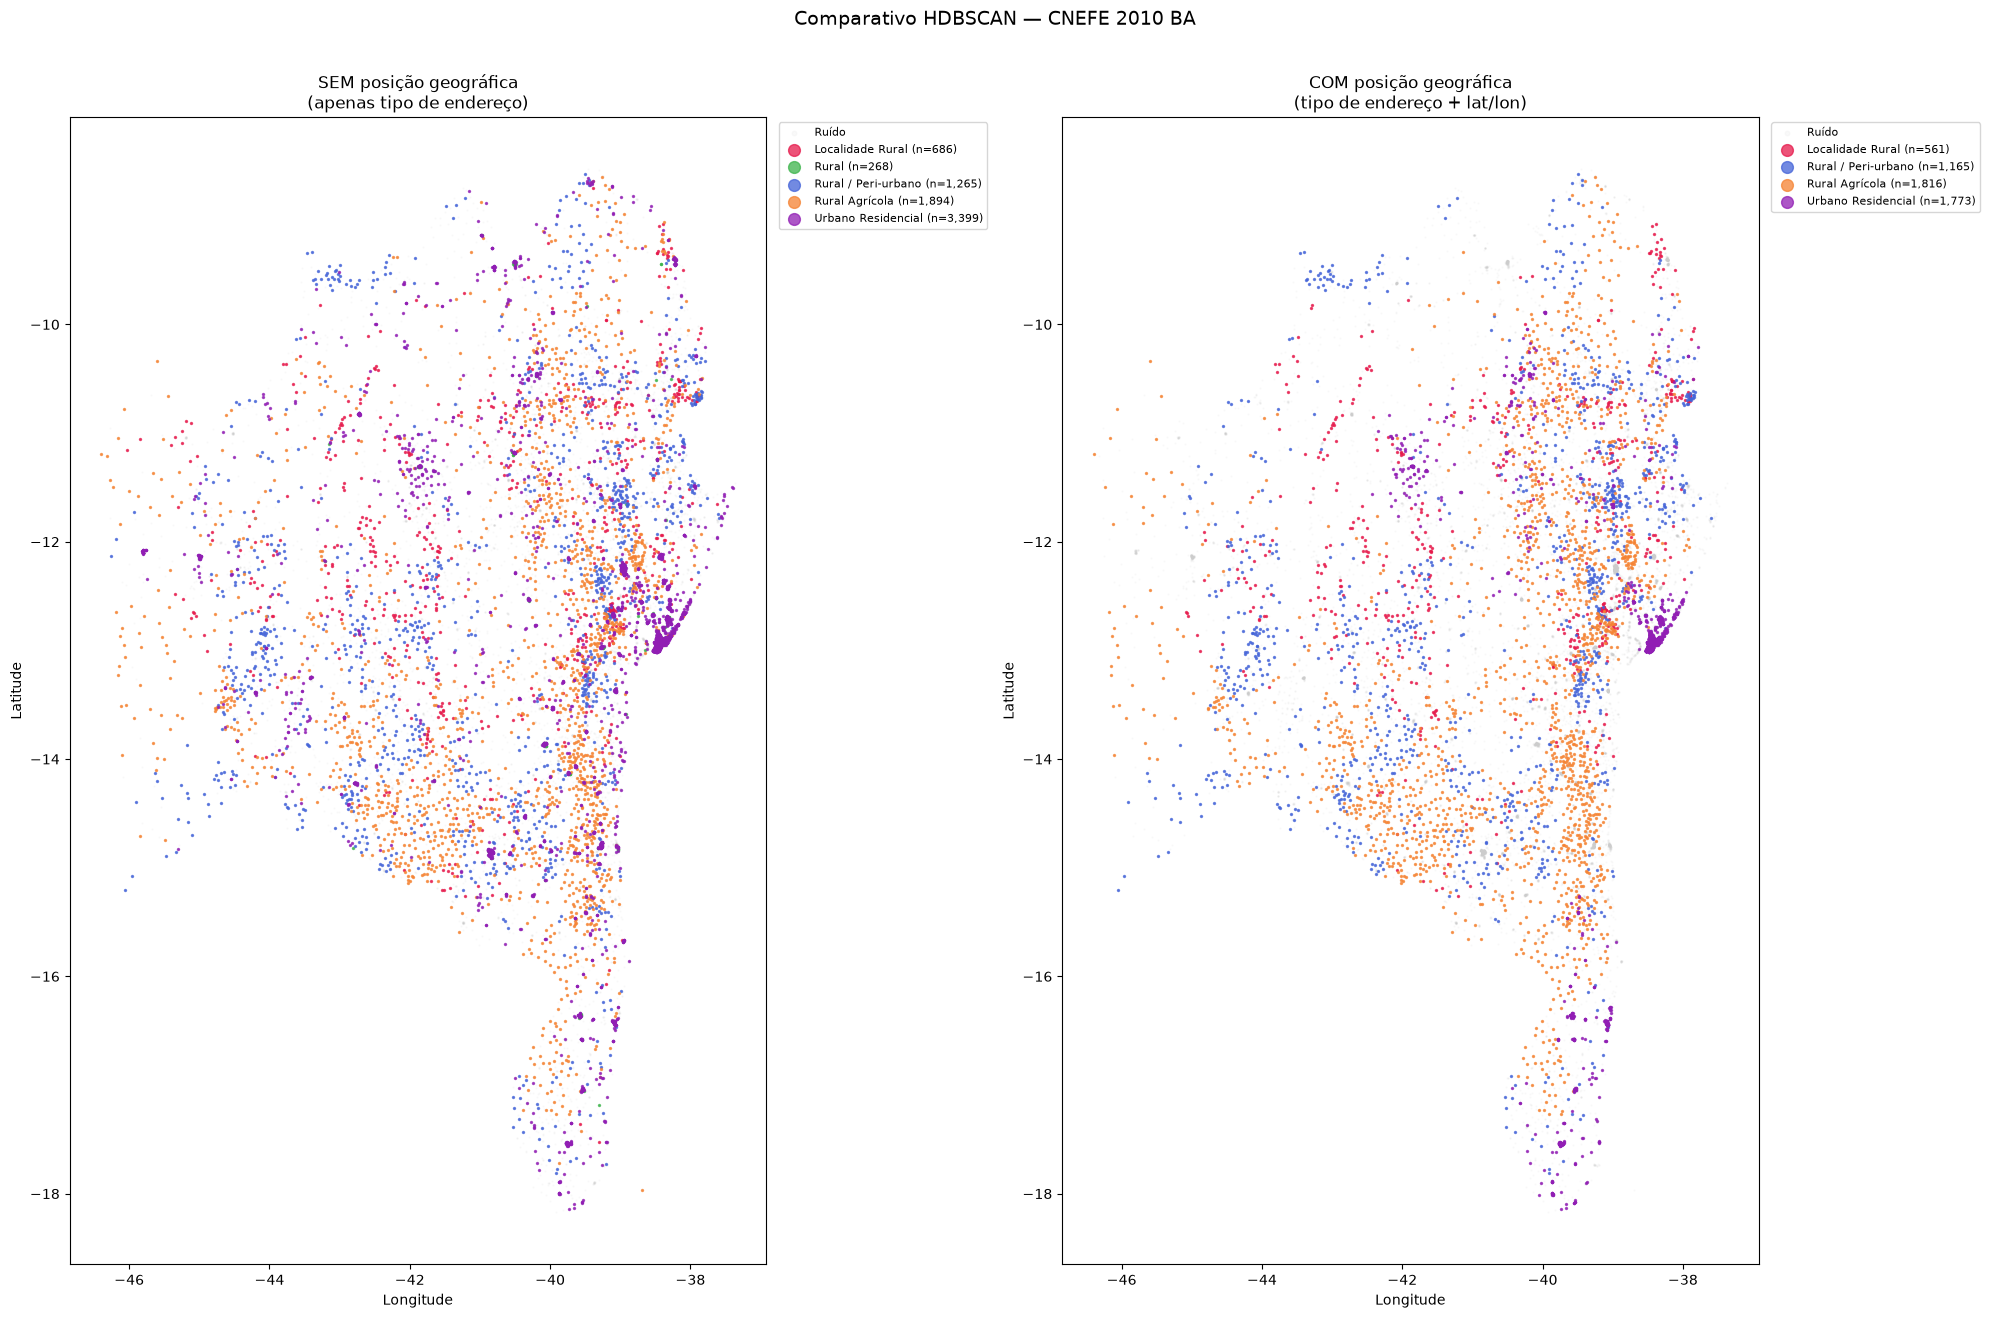

In [7]:
# Variáveis necessárias
CORES_FORTES = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
                '#00b4d8','#f032e6','#bfef45','#9A6324','#469990',
                '#800000','#000075','#ff6b6b','#06d6a0','#ffd166']

NOMES_2010 = {
    'prop_urbano': 'Urbano', 'prop_rural': 'Rural',
    'prop_rua': 'Urbano Residencial', 'prop_avenida': 'Urbano Comercial',
    'prop_travessa': 'Urbano Denso', 'prop_praca': 'Urbano Central',
    'prop_alameda': 'Urbano Residencial', 'prop_beco': 'Urbano Denso',
    'prop_fazenda': 'Rural Agrícola', 'prop_estrada': 'Rural / Peri-urbano',
    'prop_caminho': 'Rural', 'prop_rodovia': 'Peri-urbano',
    'prop_sitio': 'Rural Agrícola', 'prop_povoado': 'Localidade Rural',
}

# Garante cluster_nome em df_2010 independentemente da ordem de execução
if 'cluster_nome' not in df_2010.columns:
    perfil_z_tmp = df_2010[df_2010['cluster'] != -1].groupby('cluster')[FEATURES].mean()
    nomes_tmp = {cid: NOMES_2010[row.idxmax()] for cid, row in perfil_z_tmp.iterrows()}
    df_2010['cluster_nome'] = df_2010['cluster'].map(
        lambda x: nomes_tmp.get(x, 'Ruído') if x != -1 else 'Ruído'
    )

# Constrói df_2010_geo com coordenadas de 2022
df_coords_exp = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')[
    ['COD_SETOR', 'lat_centroide', 'lon_centroide']
].copy()
df_coords_exp['cod_setor'] = df_coords_exp['COD_SETOR'].str[:-1]

df_2010_geo = df_2010.merge(
    df_coords_exp[['cod_setor', 'lat_centroide', 'lon_centroide']],
    on='cod_setor', how='inner'
)

# Nomeia clusters do experimento COM geo
perfil_z_geo = df_geo[df_geo['cluster_geo'] != -1].groupby('cluster_geo')[FEATURES].mean()
nomes_geo = {cid: NOMES_2010[row.idxmax()] for cid, row in perfil_z_geo.iterrows()}
df_geo['cluster_nome_geo'] = df_geo['cluster_geo'].map(
    lambda x: nomes_geo.get(x, 'Ruído') if x != -1 else 'Ruído'
)

# Paleta compartilhada (mesmo nome = mesma cor nos dois mapas)
todos_nomes = sorted(set(
    df_2010_geo[df_2010_geo['cluster'] != -1]['cluster_nome'].unique().tolist() +
    df_geo[df_geo['cluster_geo'] != -1]['cluster_nome_geo'].unique().tolist()
))
palette_exp = {n: CORES_FORTES[i % len(CORES_FORTES)] for i, n in enumerate(todos_nomes)}

fig, axes = plt.subplots(1, 2, figsize=(20, 13))

for ax, titulo, df_plot, col_nome, col_cluster in [
    (axes[0], 'SEM posição geográfica\n(apenas tipo de endereço)',
     df_2010_geo, 'cluster_nome', 'cluster'),
    (axes[1], 'COM posição geográfica\n(tipo de endereço + lat/lon)',
     df_geo,     'cluster_nome_geo', 'cluster_geo'),
]:
    noise = df_plot[df_plot[col_cluster] == -1]
    ax.scatter(noise['lon_centroide'], noise['lat_centroide'],
               s=0.3, c='#cccccc', alpha=0.1, label='Ruído')

    for nome in todos_nomes:
        sub = df_plot[df_plot[col_nome] == nome]
        if len(sub):
            ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
                       s=2, alpha=0.75, color=palette_exp[nome],
                       label=f'{nome} (n={len(sub):,})')

    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

fig.suptitle('Comparativo HDBSCAN — CNEFE 2010 BA', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/comparativo_sem_com_geo_2010_ba.png', dpi=150, bbox_inches='tight')
plt.show()

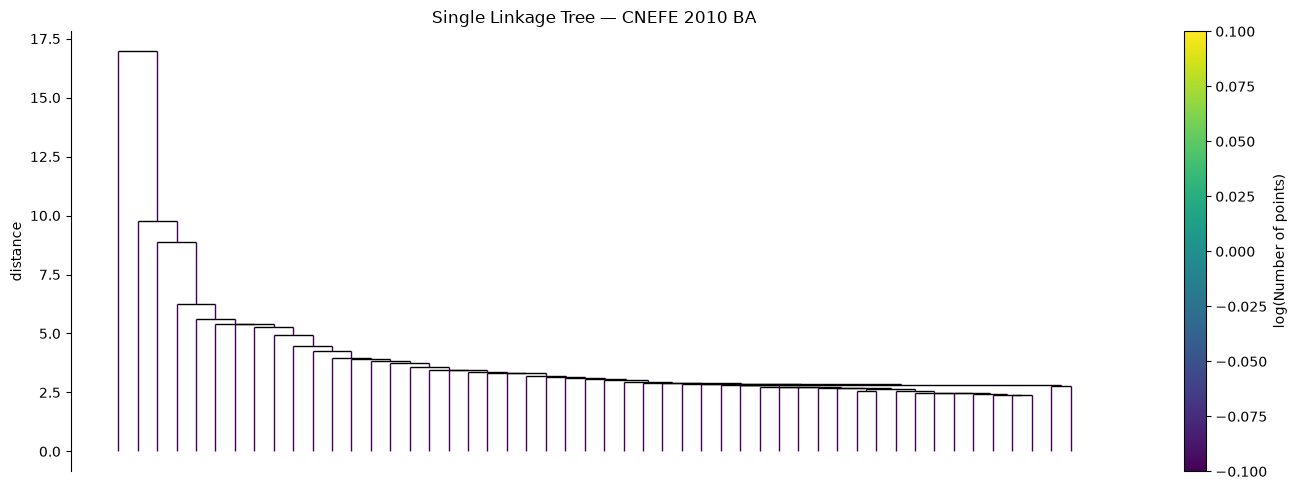

In [8]:
# Single Linkage Tree
fig, ax = plt.subplots(figsize=(14, 5))
clusterer.single_linkage_tree_.plot(
    truncate_mode='lastp', p=50,
    vary_line_width=False,
    cmap='viridis', colorbar=True, axis=ax
)
ax.set_title('Single Linkage Tree — CNEFE 2010 BA')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/single_linkage_tree_2010_ba.png', dpi=150)
plt.show()

In [9]:
# Silhouette
mask = df_2010['cluster'] != -1
if mask.sum() > 1 and df_2010.loc[mask, 'cluster'].nunique() > 1:
    score = silhouette_score(X[mask], df_2010.loc[mask, 'cluster'], sample_size=10000, random_state=42)
    print(f'Silhouette Score 2010: {score:.4f}')

Silhouette Score 2010: 0.6858


In [10]:
# Nomenclatura dos clusters 2010 — sem sufixo numérico
NOMES_2010 = {
    'prop_rua':      'Urbano Residencial',
    'prop_avenida':  'Urbano Comercial',
    'prop_travessa': 'Urbano Denso',
    'prop_praca':    'Urbano Central',
    'prop_alameda':  'Urbano Residencial',
    'prop_beco':     'Urbano Denso',
    'prop_fazenda':  'Rural Agrícola',
    'prop_estrada':  'Rural / Peri-urbano',
    'prop_caminho':  'Rural',
    'prop_rodovia':  'Peri-urbano',
    'prop_sitio':    'Rural Agrícola',
    'prop_povoado':  'Localidade Rural',
}

perfil_z = df_2010[df_2010['cluster'] != -1].groupby('cluster')[FEATURES].mean()

nomes_2010 = {cid: NOMES_2010[row.idxmax()] for cid, row in perfil_z.iterrows()}
df_2010['cluster_nome'] = df_2010['cluster'].map(
    lambda x: nomes_2010.get(x, 'Ruído') if x != -1 else 'Ruído'
)

print('Tipos de cluster 2010:')
tamanhos_nome = df_2010[df_2010['cluster'] != -1]['cluster_nome'].value_counts().sort_index()
for nome, n in tamanhos_nome.items():
    print(f'  {nome:<30} (n={n:,})')

Tipos de cluster 2010:
  Localidade Rural               (n=881)
  Rural                          (n=323)
  Rural / Peri-urbano            (n=1,610)
  Rural Agrícola                 (n=2,403)
  Urbano Residencial             (n=3,926)


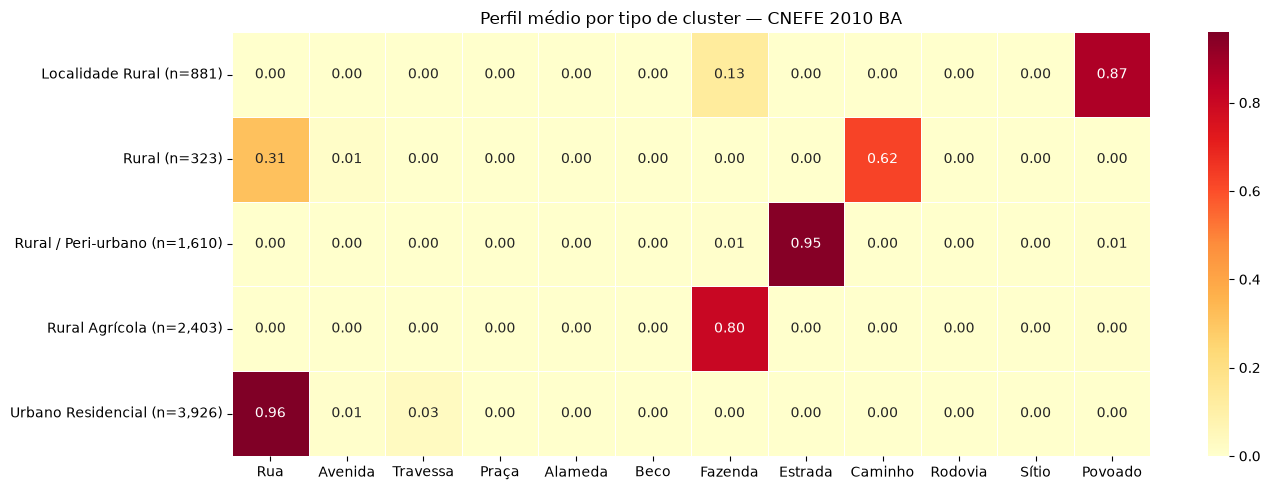

In [11]:
# Heatmap — agrega por cluster_nome (clusters do mesmo tipo unidos)
FEAT_LABEL = {
    'prop_urbano': 'Urbano', 'prop_rural': 'Rural',
    'prop_rua': 'Rua', 'prop_avenida': 'Avenida',
    'prop_travessa': 'Travessa', 'prop_praca': 'Praça',
    'prop_alameda': 'Alameda', 'prop_beco': 'Beco',
    'prop_fazenda': 'Fazenda', 'prop_estrada': 'Estrada',
    'prop_caminho': 'Caminho', 'prop_rodovia': 'Rodovia',
    'prop_sitio': 'Sítio', 'prop_povoado': 'Povoado',
}

perfil = (df_2010[df_2010['cluster'] != -1]
          .groupby('cluster_nome')[FEATURES]
          .mean()
          .rename(columns=FEAT_LABEL))

tamanhos_nome = df_2010[df_2010['cluster'] != -1]['cluster_nome'].value_counts()
perfil.index = [f"{nome} (n={tamanhos_nome[nome]:,})" for nome in perfil.index]

fig, ax = plt.subplots(figsize=(14, max(5, len(perfil) * 0.55 + 1)))
sns.heatmap(perfil, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Perfil médio por tipo de cluster — CNEFE 2010 BA')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/perfil_clusters_2010_ba.png', dpi=150)
plt.show()

In [12]:
# Salvar
df_2010.to_parquet(OUTPUT_DIR / 'setores_clusterizados_2010_ba.parquet', index=False)
print('Salvo: outputs/setores_clusterizados_2010_ba.parquet')

Salvo: outputs/setores_clusterizados_2010_ba.parquet


Setores com match em ambos os anos: 7,512
          cluster_2010         cluster_2022
0   Urbano Residencial  Setor Urbano Típico
1  Rural / Peri-urbano  Setor Urbano Típico
2  Rural / Peri-urbano  Setor Urbano Típico
3                Rural  Setor Urbano Típico
4                Rural  Setor Urbano Típico


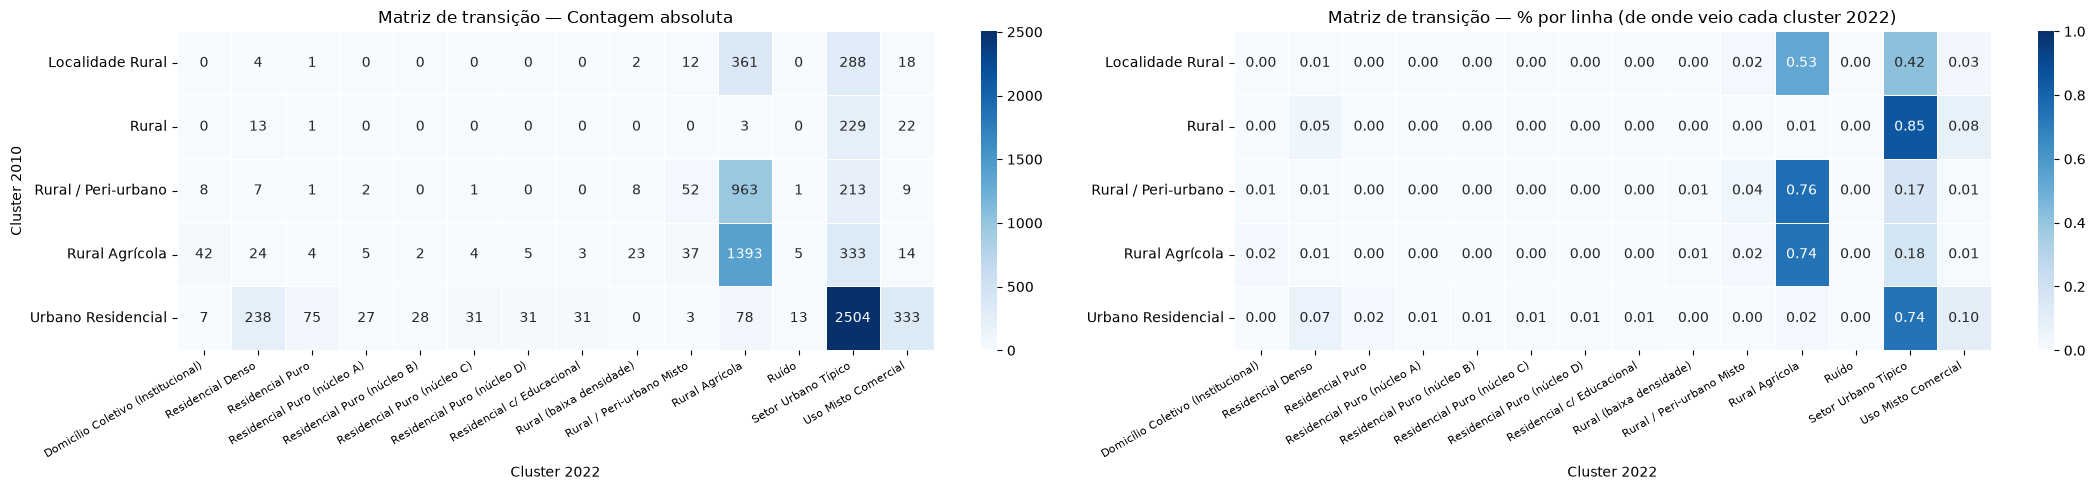

In [13]:
# Matriz de transição: cluster 2010 → cluster 2022
# Carrega direto dos parquets para não depender do estado da sessão
df_2010_saved = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados_2010_ba.parquet')
df_2022_saved = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')

# Códigos de 2022 têm sufixo 'P' — removido antes do join
df_2022_saved['cod_setor'] = df_2022_saved['COD_SETOR'].str[:-1]

df_trans = (df_2010_saved[df_2010_saved['cluster'] != -1]
            .merge(
                df_2022_saved[['cod_setor', 'cluster_nome']].rename(columns={'cluster_nome': 'cluster_2022'}),
                on='cod_setor', how='inner'
            )
            .rename(columns={'cluster_nome': 'cluster_2010'}))

print(f'Setores com match em ambos os anos: {len(df_trans):,}')
print(df_trans[['cluster_2010', 'cluster_2022']].head())

matriz_abs = pd.crosstab(df_trans['cluster_2010'], df_trans['cluster_2022'])
matriz_pct = matriz_abs.div(matriz_abs.sum(axis=1), axis=0).round(2)

fig, axes = plt.subplots(1, 2, figsize=(22, max(5, len(matriz_pct) * 0.6 + 1)))

sns.heatmap(matriz_abs, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Matriz de transição — Contagem absoluta')
axes[0].set_xlabel('Cluster 2022')
axes[0].set_ylabel('Cluster 2010')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)

sns.heatmap(matriz_pct, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Matriz de transição — % por linha (de onde veio cada cluster 2022)')
axes[1].set_xlabel('Cluster 2022')
axes[1].set_ylabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/matriz_transicao_2010_2022_ba.png', dpi=150)
plt.show()

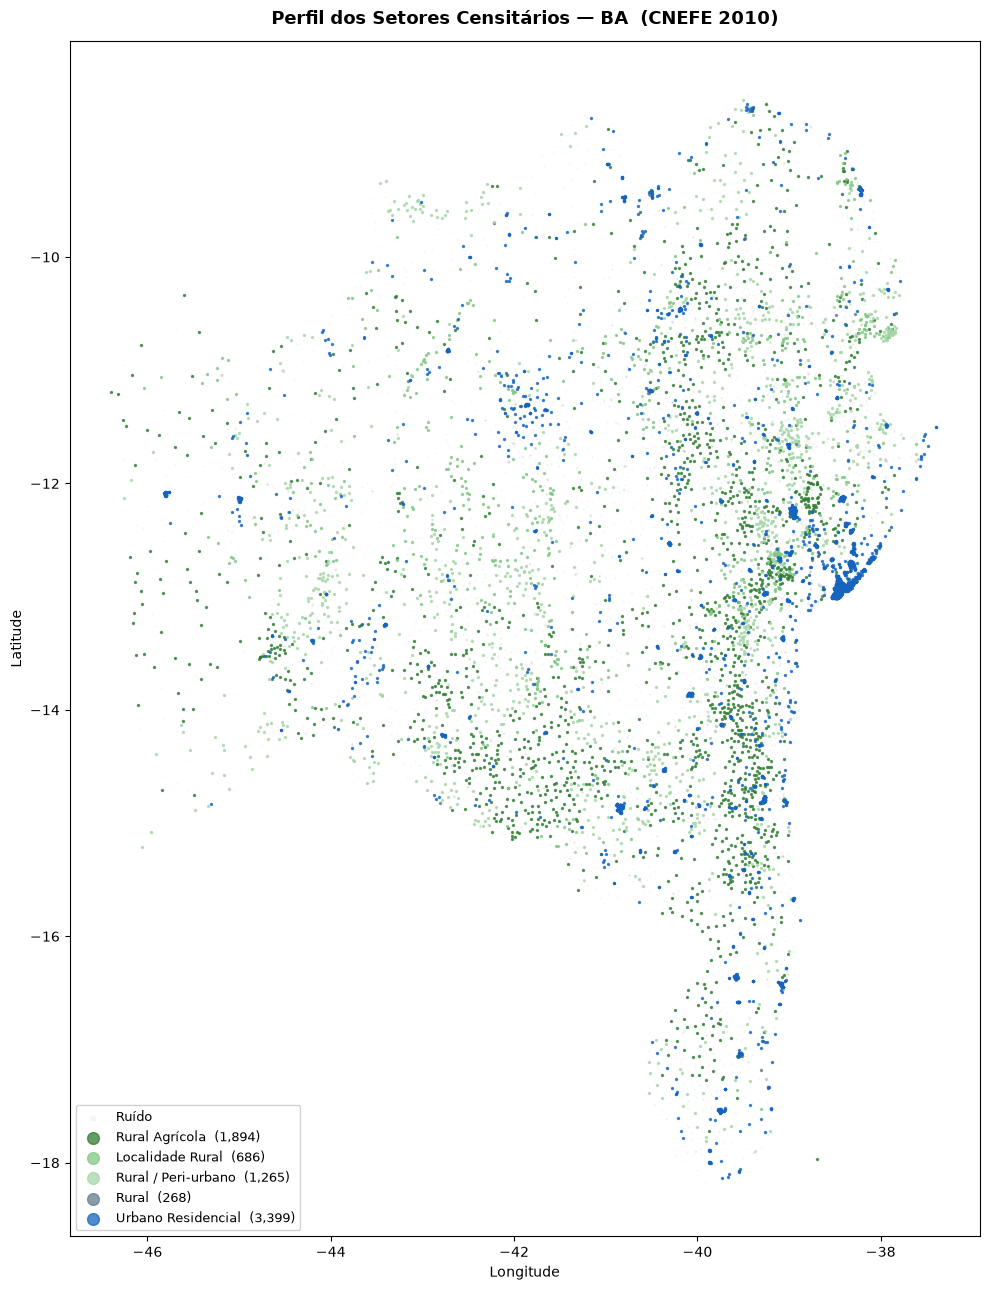

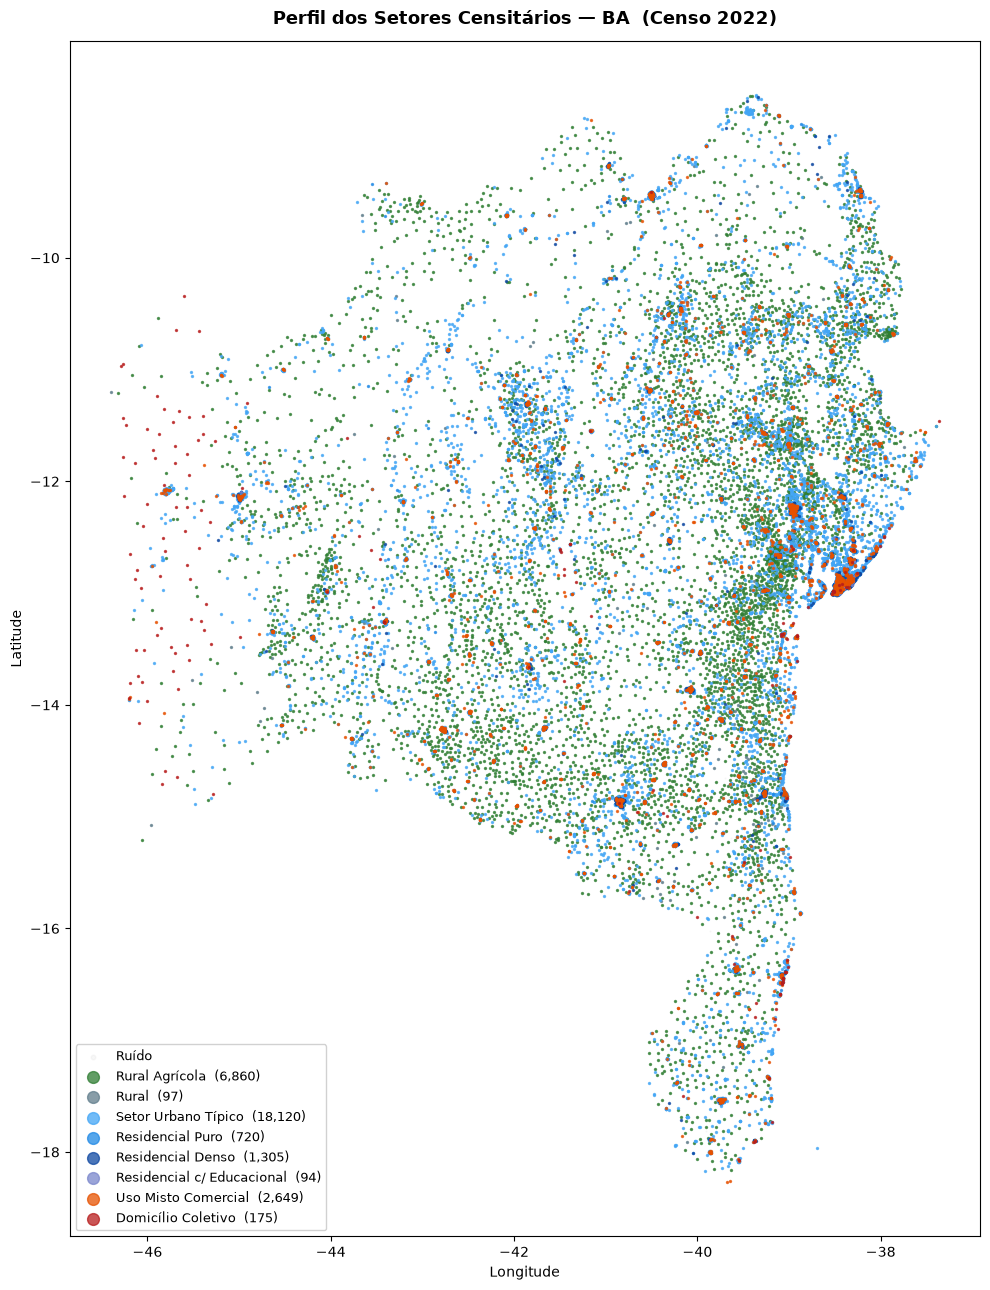

In [14]:
# Paleta harmonizada: mesma cor para tipos equivalentes em 2010 e 2022
PALETTE = {
    'Rural Agrícola':              '#2e7d32',
    'Localidade Rural':            '#81c784',
    'Rural / Peri-urbano':         '#a5d6a7',
    'Rural / Peri-urbano Misto':   '#a5d6a7',
    'Rural':                       '#607d8b',
    'Urbano Residencial':          '#1565c0',
    'Setor Urbano Típico':         '#42a5f5',
    'Residencial Puro':            '#1e88e5',
    'Residencial Denso':           '#0d47a1',
    'Residencial c/ Educacional':  '#7986cb',
    'Uso Misto Comercial':         '#e65100',
    'Domicílio Coletivo':          '#b71c1c',
    'Ruído':                       '#cccccc',
}
MACRO_2010 = {
    'Rural Agrícola': 'Rural', 'Localidade Rural': 'Rural',
    'Rural / Peri-urbano': 'Rural', 'Rural': 'Rural',
    'Urbano Residencial': 'Urbano',
}
MACRO_2022 = {
    'Rural Agrícola': 'Rural', 'Rural / Peri-urbano': 'Rural',
    'Rural / Peri-urbano Misto': 'Rural', 'Rural': 'Rural',
    'Setor Urbano Típico': 'Urbano', 'Residencial Puro': 'Urbano',
    'Residencial Denso': 'Urbano', 'Residencial c/ Educacional': 'Urbano',
    'Uso Misto Comercial': 'Misto', 'Domicílio Coletivo': 'Institucional',
}
COR_MACRO = {
    'Rural → Rural':        '#2e7d32',
    'Rural → Urbano':       '#ff6f00',
    'Rural → Misto':        '#f9a825',
    'Rural → Institucional':'#ab47bc',
    'Urbano → Urbano':      '#1565c0',
    'Urbano → Rural':       '#795548',
    'Urbano → Misto':       '#e65100',
    'Urbano → Institucional':'#b71c1c',
    'Sem match':            '#e0e0e0',
}

df_10 = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados_2010_ba.parquet')
df_22 = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')
df_22['cod_setor'] = df_22['COD_SETOR'].str[:-1]
df_10_geo = df_10.merge(df_22[['cod_setor','lat_centroide','lon_centroide']],
                        on='cod_setor', how='inner')

def plot_mapa(df_plot, col_nome, titulo, fname, tipos_ordem):
    fig, ax = plt.subplots(figsize=(10, 13))
    noise = df_plot[df_plot['cluster'] == -1]
    if len(noise):
        ax.scatter(noise['lon_centroide'], noise['lat_centroide'],
                   s=0.3, c='#cccccc', alpha=0.15, label='Ruído', zorder=1)
    for tipo in tipos_ordem:
        sub = df_plot[df_plot[col_nome] == tipo]
        if len(sub) == 0:
            continue
        ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
                   s=2, alpha=0.75, color=PALETTE[tipo], zorder=2,
                   label=f'{tipo}  ({len(sub):,})')
    ax.legend(markerscale=6, loc='lower left', fontsize=9,
              framealpha=0.9, edgecolor='#cccccc')
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'figures/{fname}', dpi=150, bbox_inches='tight')
    plt.show()

# ── Mapa 2010 ────────────────────────────────────────────────────────────────
tipos_2010 = ['Rural Agrícola','Localidade Rural','Rural / Peri-urbano',
              'Rural','Urbano Residencial']
plot_mapa(df_10_geo, 'cluster_nome',
          'Perfil dos Setores Censitários — BA  (CNEFE 2010)',
          'mapa_perfil_2010_ba.png', tipos_2010)

# ── Mapa 2022 ────────────────────────────────────────────────────────────────
tipos_2022 = ['Rural Agrícola','Rural / Peri-urbano Misto','Rural',
              'Setor Urbano Típico','Residencial Puro','Residencial Denso',
              'Residencial c/ Educacional','Uso Misto Comercial','Domicílio Coletivo']
plot_mapa(df_22, 'cluster_tipo',
          'Perfil dos Setores Censitários — BA  (Censo 2022)',
          'mapa_perfil_2022_ba.png', tipos_2022)

Transições encontradas:
  Urbano → Urbano                     2,965  (39.6%)
  Rural → Rural                       2,854  (38.1%)
  Rural → Urbano                      1,140  (15.2%)
  Urbano → Misto                        333  (4.4%)
  Urbano → Rural                         81  (1.1%)
  Rural → Misto                          63  (0.8%)
  Rural → Institucional                  50  (0.7%)
  Urbano → Institucional                  7  (0.1%)


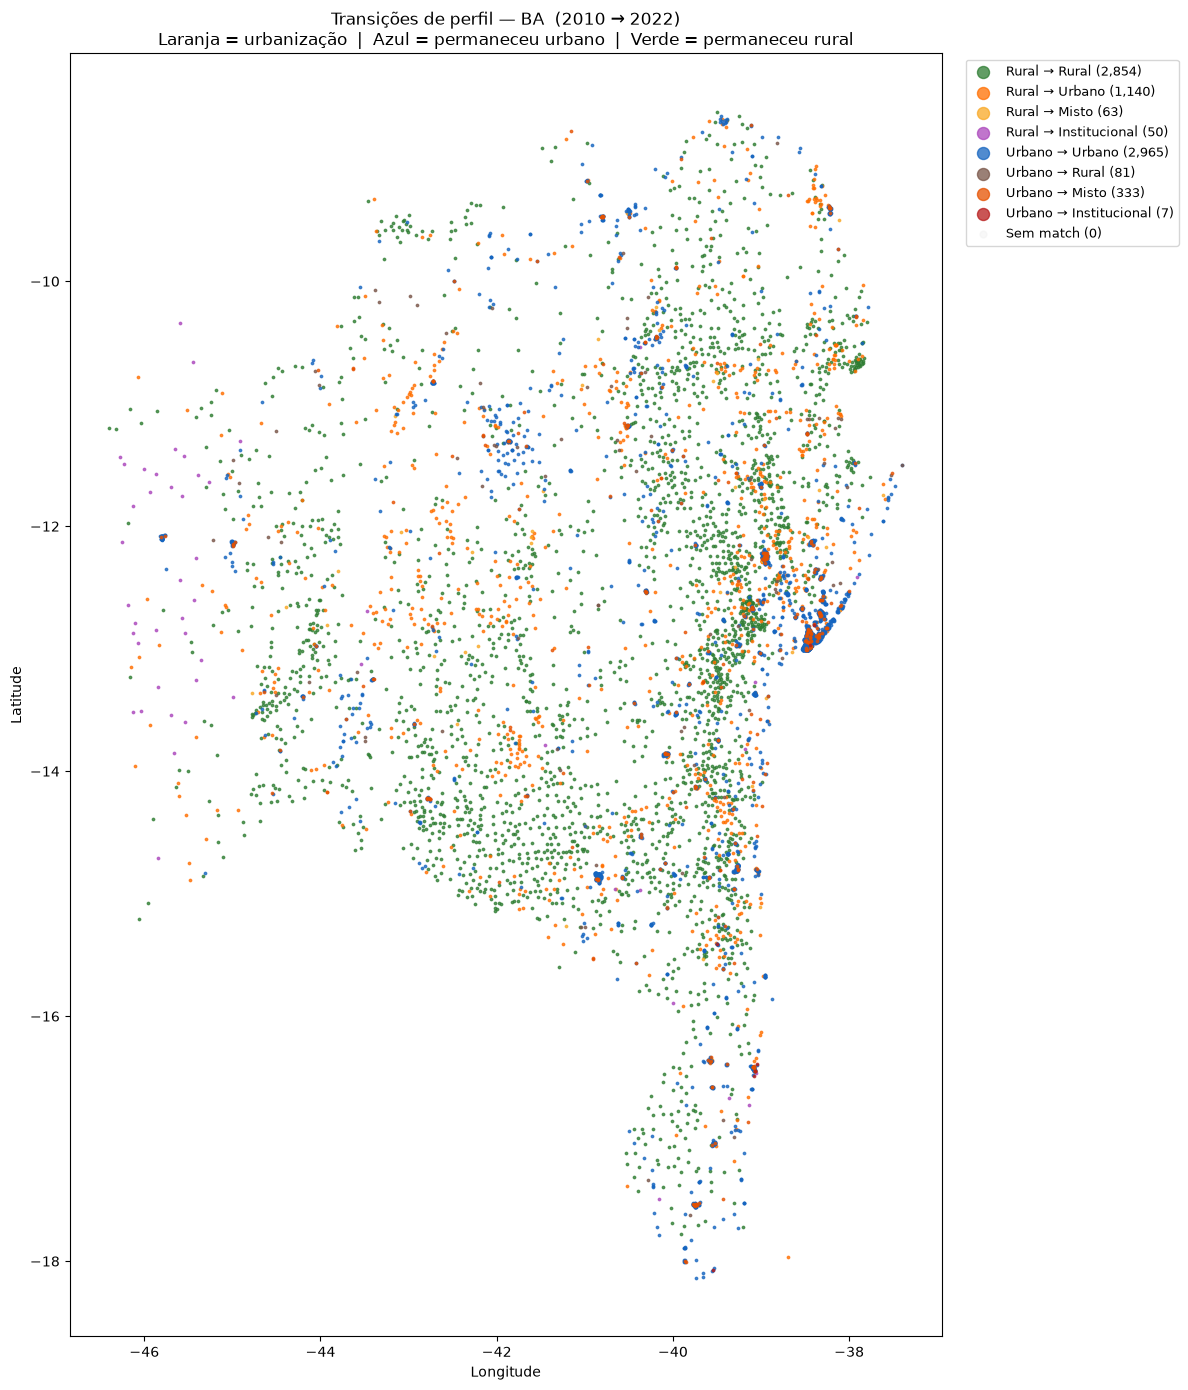

In [15]:
# ── Mapa de transições: o que MUDOU entre 2010 e 2022 ───────────────────────
df_trans_mapa = (
    df_10[df_10['cluster'] != -1][['cod_setor','cluster_nome']]
    .rename(columns={'cluster_nome': 'tipo_2010'})
    .merge(
        df_22[df_22['cluster'] != -1][['cod_setor','cluster_tipo','lat_centroide','lon_centroide']]
        .rename(columns={'cluster_tipo': 'tipo_2022'}),
        on='cod_setor', how='inner'
    )
)

df_trans_mapa['macro_2010'] = df_trans_mapa['tipo_2010'].map(MACRO_2010)
df_trans_mapa['macro_2022'] = df_trans_mapa['tipo_2022'].map(MACRO_2022)
df_trans_mapa['transicao']  = (df_trans_mapa['macro_2010'] + ' → ' +
                                df_trans_mapa['macro_2022'])

# resume as transições
print('Transições encontradas:')
tab = df_trans_mapa['transicao'].value_counts()
for t, n in tab.items():
    pct = n / len(df_trans_mapa) * 100
    print(f'  {t:<35} {n:>5,}  ({pct:.1f}%)')

# mapa
fig, ax = plt.subplots(figsize=(12, 14))

for transicao, cor in COR_MACRO.items():
    sub = df_trans_mapa[df_trans_mapa['transicao'] == transicao]
    if len(sub) == 0:
        continue
    ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
               s=3, alpha=0.75, color=cor,
               label=f'{transicao} ({len(sub):,})')

# setores sem match
sem_match = df_10[df_10['cluster'] != -1].merge(
    df_22[['cod_setor']], on='cod_setor', how='left', indicator=True
)
sem_match = sem_match[sem_match['_merge'] == 'left_only']
if len(sem_match):
    sem_match = sem_match.merge(df_22[['cod_setor','lat_centroide','lon_centroide']],
                                on='cod_setor', how='left').dropna()
    ax.scatter(sem_match['lon_centroide'], sem_match['lat_centroide'],
               s=1, alpha=0.2, color='#e0e0e0', label=f'Sem match ({len(sem_match):,})')

ax.legend(markerscale=5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_title('Transições de perfil — BA  (2010 → 2022)\n'
             'Laranja = urbanização  |  Azul = permaneceu urbano  |  Verde = permaneceu rural',
             fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/mapa_transicoes_2010_2022_ba.png',
            dpi=150, bbox_inches='tight')
plt.show()


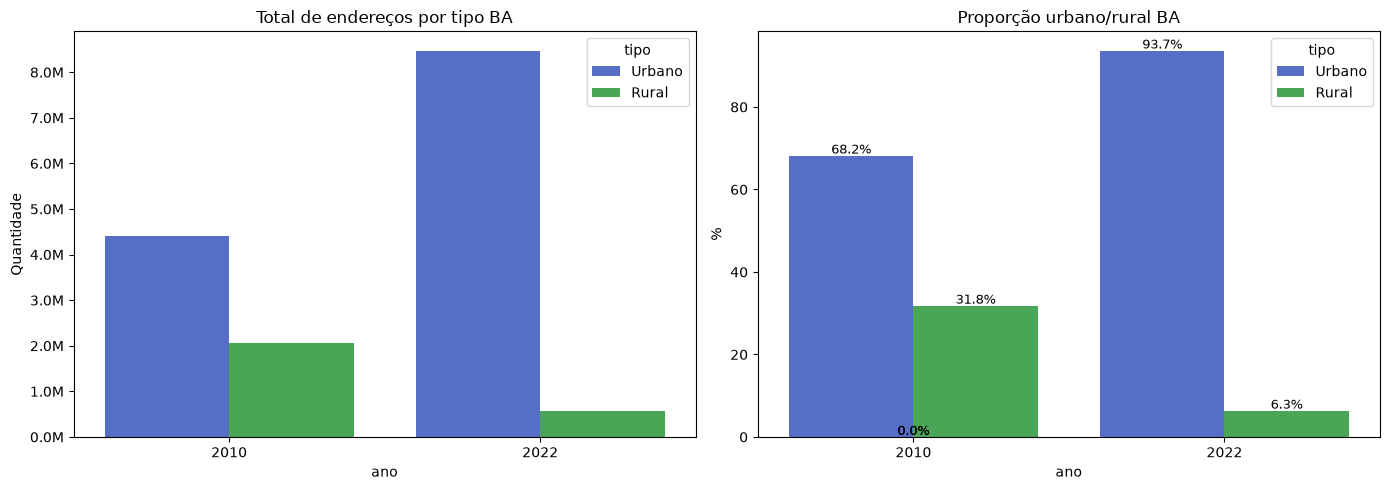

In [16]:
# Comparativo urbano/rural: total de endereços 2010 vs 2022
total_2010 = con.execute(f"""
    SELECT situacao, COUNT(*) as total
    FROM read_parquet({CNEFE_2010})
    WHERE uf = '29'
    GROUP BY situacao
""").df()
total_2010['ano']  = '2010'
total_2010['tipo'] = total_2010['situacao'].map({'1': 'Urbano', '2': 'Rural'})

total_2022 = con.execute("""
    SELECT
        CASE WHEN COD_ESPECIE = 3 THEN 'Rural' ELSE 'Urbano' END AS tipo,
        COUNT(*) as total
    FROM read_parquet('../data/censo 2022/29_BA.parquet')
    GROUP BY tipo
""").df()
total_2022['ano'] = '2022'

df_comp = pd.concat([
    total_2010[['ano', 'tipo', 'total']],
    total_2022[['ano', 'tipo', 'total']]
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras absolutas
sns.barplot(data=df_comp, x='ano', y='total', hue='tipo',
            palette={'Urbano': '#4363d8', 'Rural': '#3cb44b'}, ax=axes[0])
axes[0].set_title('Total de endereços por tipo BA')
axes[0].set_ylabel('Quantidade')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Barras percentuais
df_pct = df_comp.copy()
for ano in ['2010', '2022']:
    tot = df_pct[df_pct['ano'] == ano]['total'].sum()
    df_pct.loc[df_pct['ano'] == ano, 'pct'] = df_pct.loc[df_pct['ano'] == ano, 'total'] / tot * 100

sns.barplot(data=df_pct, x='ano', y='pct', hue='tipo',
            palette={'Urbano': '#4363d8', 'Rural': '#3cb44b'}, ax=axes[1])
axes[1].set_title('Proporção urbano/rural BA')
axes[1].set_ylabel('%')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/comparativo_urbano_rural_2010_2022_ba.png', dpi=150)
plt.show()